### Задание

1) Модифицируйте код и реализуйте [Wasserstein GAN](https://arxiv.org/abs/1701.07875) ([From GAN to WGAN
](https://lilianweng.github.io/posts/2017-08-20-gan/)) используя weight clipping. (1 балл)

2) Замените  weight clipping на [gradient penalty](https://arxiv.org/pdf/1704.00028v3.pdf). (1 балл)

3) Добавьте к обучению WGAN условие на метку, продемонстрируйте [условную генерацию](https://arxiv.org/pdf/1411.1784.pdf).  (2 балл)

4) Напишите отчет о том, что попробовали, какие результаты получили, какую архитектуру использовали, как вам кажется надо обучать GAN, чтобы добиться сходимости? Каждый пункт обязательно сопроводите визуализациями (1 балл)

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchvision
import matplotlib.pyplot as plt
import numpy as np

from torch.autograd import Variable
from torch.autograd import grad


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
class Config:
    pass

config = Config()
config.mnist_path = None
config.batch_size = 16
config.num_workers = 3
config.num_epochs = 10
config.noise_size = 50
config.print_freq = 100
config.n_critic = 5          # для WGAN
config.clip_value = 0.01     # для weight clipping
config.lambda_gp = 10.0      # для gradient penalty
config.num_classes = 10 


In [5]:
train = torchvision.datasets.FashionMNIST("fashion_mnist", 
                                          train=True, 
                                          transform=torchvision.transforms.ToTensor(), 
                                          download=True)

100%|██████████| 26.4M/26.4M [00:36<00:00, 728kB/s] 


Extracting fashion_mnist\FashionMNIST\raw\train-images-idx3-ubyte.gz to fashion_mnist\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 496kB/s]


Extracting fashion_mnist\FashionMNIST\raw\train-labels-idx1-ubyte.gz to fashion_mnist\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 4.17MB/s]


Extracting fashion_mnist\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to fashion_mnist\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Extracting fashion_mnist\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to fashion_mnist\FashionMNIST\raw



In [6]:
dataloader = DataLoader(train, batch_size=16, shuffle=True)

In [7]:
len(dataloader)

3750

In [8]:
for image, cat in dataloader:
    break

In [9]:
image.size()

torch.Size([16, 1, 28, 28])

In [10]:
28*28

784

In [11]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential( 
            nn.Linear(config.noise_size, 200),
            nn.ReLU(inplace=True),
            nn.Linear(200, 28*28),
            nn.Sigmoid())
        
    def forward(self, x):
        return self.model(x)
    
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 200),
            nn.ReLU(inplace=True),
            nn.Linear(200, 50),
            nn.ReLU(inplace=True),
            nn.Linear(50, 1), 
            nn.Sigmoid())
    def forward(self, x):
        return self.model(x)

In [13]:
generator = Generator()
discriminator = Discriminator()

In [14]:
optim_G = optim.Adam(params=generator.parameters(), lr=0.0001)
optim_D = optim.Adam(params=discriminator.parameters(), lr=0.0001)

criterion = nn.BCELoss()

In [15]:
input = Variable(torch.FloatTensor(config.batch_size, 28*28))
noise = Variable(torch.FloatTensor(config.batch_size, config.noise_size))
fixed_noise = Variable(torch.FloatTensor(config.batch_size, config.noise_size).normal_(0, 1))
label = Variable(torch.FloatTensor(config.batch_size))
real_label = 1
fake_label = 0

In [17]:
ERRD_x = np.zeros(config.num_epochs)
ERRD_z = np.zeros(config.num_epochs)
ERRG = np.zeros(config.num_epochs)
N = len(dataloader)

for epoch in range(config.num_epochs):
    for iteration, (images, cat) in enumerate(dataloader):
        ####### 
        # Discriminator stage: maximize log(D(x)) + log(1 - D(G(z))) 
        #######
        discriminator.zero_grad()
        
        # real
        label.data.fill_(real_label)
        input_data = images.view(images.shape[0], -1)
        output = discriminator(input_data)
        errD_x = criterion(output.view(-1), label)
        ERRD_x[epoch] += errD_x.item()
        errD_x.backward()
        
        # fake 
        noise.data.normal_(0, 1)
        fake = generator(noise)
        label.data.fill_(fake_label)
        output = discriminator(fake.detach())
        errD_z = criterion(output.view(-1), label)
        ERRD_z[epoch] += errD_z.item()
        errD_z.backward()
        
        optim_D.step()
        
        ####### 
        # Generator stage: maximize log(D(G(x))
        #######
        generator.zero_grad()
        label.data.fill_(real_label)
        output = discriminator(fake)
        errG = criterion(output.view(-1), label)
        ERRG[epoch] += errG.item()
        errG.backward()
        
        optim_G.step()
        
        if (iteration+1) % config.print_freq == 0:
            print('Epoch:{} Iter: {} errD_x: {:.2f} errD_z: {:.2f} errG: {:.2f}'.format(epoch+1,
                                                                                            iteration+1, 
                                                                                            errD_x.item(),
                                                                                            errD_z.item(), 
                                                                                            errG.item()))

Epoch:1 Iter: 100 errD_x: 0.13 errD_z: 0.11 errG: 2.34
Epoch:1 Iter: 200 errD_x: 0.20 errD_z: 0.16 errG: 2.20
Epoch:1 Iter: 300 errD_x: 0.15 errD_z: 0.11 errG: 2.62
Epoch:1 Iter: 400 errD_x: 0.48 errD_z: 0.06 errG: 2.95
Epoch:1 Iter: 500 errD_x: 0.05 errD_z: 0.09 errG: 2.59
Epoch:1 Iter: 600 errD_x: 0.05 errD_z: 0.08 errG: 2.68
Epoch:1 Iter: 700 errD_x: 0.07 errD_z: 0.06 errG: 3.03
Epoch:1 Iter: 800 errD_x: 0.09 errD_z: 0.09 errG: 2.66
Epoch:1 Iter: 900 errD_x: 0.11 errD_z: 0.17 errG: 2.11
Epoch:1 Iter: 1000 errD_x: 0.07 errD_z: 0.24 errG: 1.81
Epoch:1 Iter: 1100 errD_x: 0.08 errD_z: 0.24 errG: 1.84
Epoch:1 Iter: 1200 errD_x: 0.06 errD_z: 0.15 errG: 2.43
Epoch:1 Iter: 1300 errD_x: 0.07 errD_z: 0.19 errG: 2.15
Epoch:1 Iter: 1400 errD_x: 0.08 errD_z: 0.24 errG: 1.97
Epoch:1 Iter: 1500 errD_x: 0.07 errD_z: 0.16 errG: 2.48
Epoch:1 Iter: 1600 errD_x: 0.14 errD_z: 0.09 errG: 2.89
Epoch:1 Iter: 1700 errD_x: 0.10 errD_z: 0.12 errG: 2.60
Epoch:1 Iter: 1800 errD_x: 0.08 errD_z: 0.12 errG: 2.57
E

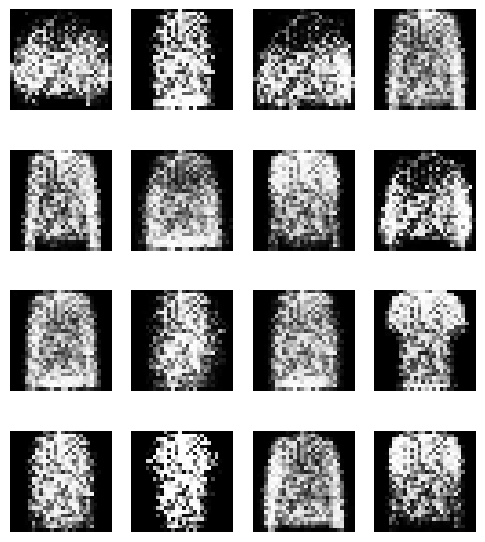

In [21]:
noise.data.normal_(0, 1)
fake = generator(noise)

plt.figure(figsize=(6, 7))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake[i].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.axis('off')

WGAN с weight clipping

In [ ]:
class GeneratorWGAN(nn.Module):
    def __init__(self, noise_dim=50):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 28*28),
            nn.Sigmoid()
        )

    def forward(self, z):
        out = self.model(z)
        return out.view(-1, 1, 28, 28)  # (B,1,28,28)


class CriticWGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x) 


G = GeneratorWGAN(config.noise_size).to(device)
C = CriticWGAN().to(device)

opt_G = optim.RMSprop(G.parameters(), lr=5e-5)
opt_C = optim.RMSprop(C.parameters(), lr=5e-5)

In [28]:
G_losses_wc = []
C_losses_wc = []

for epoch in range(config.num_epochs):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # === Обучаем критик несколько раз ===
        for _ in range(config.n_critic):
            C.zero_grad()

            # реальные
            real_scores = C(real_imgs)           # (B,1)
            loss_real = -real_scores.mean()      # хотим МАКСИМИЗИРОВАТЬ real_scores

            # фейковые
            z = torch.randn(batch_size, config.noise_size, device=device)
            fake_imgs = G(z).detach()           # не обновляем G здесь
            fake_scores = C(fake_imgs)
            loss_fake = fake_scores.mean()      # хотим МИНИМИЗИРОВАТЬ fake_scores

            # итоговый лосс критика
            loss_C = loss_real + loss_fake
            loss_C.backward()
            opt_C.step()

            # weight clipping
            for p in C.parameters():
                p.data.clamp_(-config.clip_value, config.clip_value)

        # === Обучаем генератор ===
        G.zero_grad()
        z = torch.randn(batch_size, config.noise_size, device=device)
        fake_imgs = G(z)
        fake_scores = C(fake_imgs)
        loss_G = -fake_scores.mean()
        loss_G.backward()
        opt_G.step()

        # логируем лоссы
        G_losses_wc.append(loss_G.item())
        C_losses_wc.append(loss_C.item())

        if (i + 1) % config.print_freq == 0:
            print(
                f"[WGAN-clip] Epoch [{epoch+1}/{config.num_epochs}] "
                f"Step [{i+1}/{len(dataloader)}] "
                f"C_loss: {loss_C.item():.4f} | G_loss: {loss_G.item():.4f}"
            )

[WGAN-clip] Epoch [1/10] Step [100/3750] C_loss: -0.6474 | G_loss: 0.7985
[WGAN-clip] Epoch [1/10] Step [200/3750] C_loss: -1.2185 | G_loss: -0.2988
[WGAN-clip] Epoch [1/10] Step [300/3750] C_loss: -1.3239 | G_loss: -0.0345
[WGAN-clip] Epoch [1/10] Step [400/3750] C_loss: -1.2659 | G_loss: -0.2080
[WGAN-clip] Epoch [1/10] Step [500/3750] C_loss: -1.7988 | G_loss: -0.0567
[WGAN-clip] Epoch [1/10] Step [600/3750] C_loss: -1.2075 | G_loss: 0.3410
[WGAN-clip] Epoch [1/10] Step [700/3750] C_loss: -1.6777 | G_loss: 1.4566
[WGAN-clip] Epoch [1/10] Step [800/3750] C_loss: -0.7333 | G_loss: 0.4538
[WGAN-clip] Epoch [1/10] Step [900/3750] C_loss: -0.8207 | G_loss: -0.5741
[WGAN-clip] Epoch [1/10] Step [1000/3750] C_loss: -1.0788 | G_loss: 0.5367
[WGAN-clip] Epoch [1/10] Step [1100/3750] C_loss: -0.8262 | G_loss: 1.0364
[WGAN-clip] Epoch [1/10] Step [1200/3750] C_loss: -0.5390 | G_loss: -1.2332
[WGAN-clip] Epoch [1/10] Step [1300/3750] C_loss: -0.4051 | G_loss: -0.5610
[WGAN-clip] Epoch [1/10] St

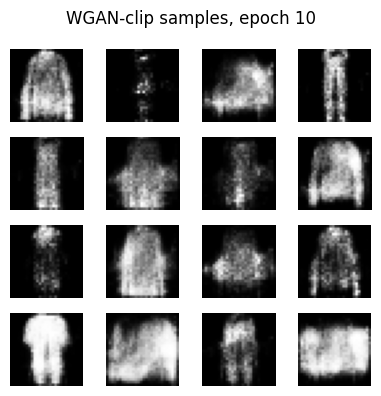

In [29]:
with torch.no_grad():
    z = torch.randn(16, config.noise_size, device=device)
    fake_sample = G(z).cpu()

    plt.figure(figsize=(4, 4))
    for k in range(16):
        plt.subplot(4, 4, k+1)
        plt.imshow(fake_sample[k, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle(f"WGAN-clip samples, epoch {epoch+1}")
    plt.tight_layout()
    plt.show()

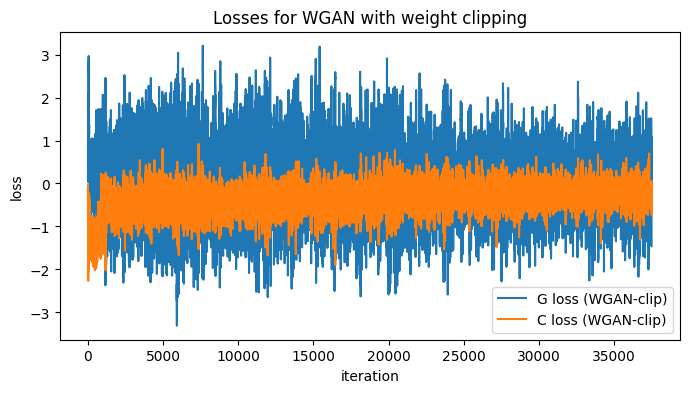

In [30]:
plt.figure(figsize=(8,4))
plt.plot(G_losses_wc, label="G loss (WGAN-clip)")
plt.plot(C_losses_wc, label="C loss (WGAN-clip)")
plt.legend()
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Losses for WGAN with weight clipping")
plt.show()

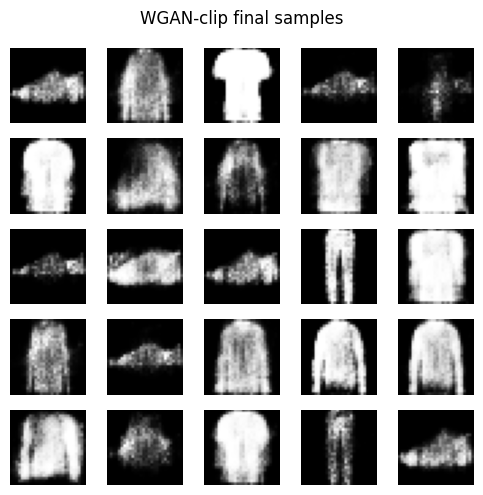

In [31]:
with torch.no_grad():
    z = torch.randn(25, config.noise_size, device=device)
    fake_final = G(z).cpu()

plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(fake_final[i,0], cmap="gray")
    plt.axis("off")
plt.suptitle("WGAN-clip final samples")
plt.tight_layout()
plt.show()

WGAN с weight clipping обучается стабильнее, чем обычный GAN, лосс критика постепенно уменьшается, и генератор начинает воспроизводить базовые формы одежды.
картины выглядят размытыми, не все классы одежды различимы, модель медленно сходится.

WGAN с gradient penalty (WGAN-GP)

In [32]:
class ConfigGP:
    pass

config_gp = ConfigGP()
config_gp.batch_size = 64
config_gp.num_epochs = 10
config_gp.noise_size = 50
config_gp.n_critic = 5
config_gp.lambda_gp = 10.0
config_gp.print_freq = 100

In [33]:
class GeneratorGP(nn.Module):
    def __init__(self, noise_dim=50):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 28*28),
            nn.Sigmoid()
        )

    def forward(self, z):
        out = self.model(z)
        return out.view(-1, 1, 28, 28)


class CriticGP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

G_gp = GeneratorGP(config_gp.noise_size).to(device)
C_gp = CriticGP().to(device)

opt_G_gp = optim.Adam(G_gp.parameters(), lr=1e-4, betas=(0.5, 0.9))
opt_C_gp = optim.Adam(C_gp.parameters(), lr=1e-4, betas=(0.5, 0.9))

In [38]:
def gradient_penalty(critic, real_imgs, fake_imgs):
    batch_size = real_imgs.size(0)
    # интерполяция между real и fake
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real_imgs)
    interpolates = (alpha * real_imgs + (1 - alpha) * fake_imgs).requires_grad_(True)

    critic_interpolates = critic(interpolates)
    ones = torch.ones_like(critic_interpolates, device=device)

    gradients = grad(
        outputs=critic_interpolates,
        inputs=interpolates,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]  # shape как у interpolates

    gradients = gradients.view(batch_size, -1)
    grad_norm = gradients.norm(2, dim=1)
    gp = ((grad_norm - 1.0) ** 2).mean()
    return gp

[WGAN-GP] Epoch [1/10] Step [100/3750] C_loss: -4.9945 | G_loss: 2.5289
[WGAN-GP] Epoch [1/10] Step [200/3750] C_loss: -5.9051 | G_loss: 1.7968
[WGAN-GP] Epoch [1/10] Step [300/3750] C_loss: -5.7999 | G_loss: 2.5617
[WGAN-GP] Epoch [1/10] Step [400/3750] C_loss: -4.7571 | G_loss: -0.8881
[WGAN-GP] Epoch [1/10] Step [500/3750] C_loss: -4.6833 | G_loss: -0.1163
[WGAN-GP] Epoch [1/10] Step [600/3750] C_loss: -4.6028 | G_loss: -0.7243
[WGAN-GP] Epoch [1/10] Step [700/3750] C_loss: -4.2082 | G_loss: -1.5915
[WGAN-GP] Epoch [1/10] Step [800/3750] C_loss: -4.6851 | G_loss: -0.5708
[WGAN-GP] Epoch [1/10] Step [900/3750] C_loss: -3.8692 | G_loss: -0.0791
[WGAN-GP] Epoch [1/10] Step [1000/3750] C_loss: -3.8955 | G_loss: -1.2145
[WGAN-GP] Epoch [1/10] Step [1100/3750] C_loss: -3.7665 | G_loss: 1.2210
[WGAN-GP] Epoch [1/10] Step [1200/3750] C_loss: -3.9686 | G_loss: 0.4490
[WGAN-GP] Epoch [1/10] Step [1300/3750] C_loss: -3.8397 | G_loss: 0.4412
[WGAN-GP] Epoch [1/10] Step [1400/3750] C_loss: -4.91

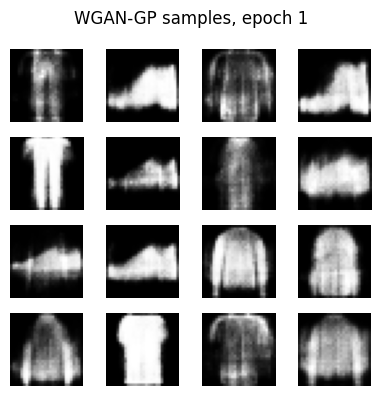

[WGAN-GP] Epoch [2/10] Step [100/3750] C_loss: -2.3261 | G_loss: 1.2812
[WGAN-GP] Epoch [2/10] Step [200/3750] C_loss: -3.4316 | G_loss: 1.2480
[WGAN-GP] Epoch [2/10] Step [300/3750] C_loss: -2.5305 | G_loss: -1.3196
[WGAN-GP] Epoch [2/10] Step [400/3750] C_loss: -3.3563 | G_loss: -0.8428
[WGAN-GP] Epoch [2/10] Step [500/3750] C_loss: -2.6144 | G_loss: 0.3144
[WGAN-GP] Epoch [2/10] Step [600/3750] C_loss: -2.9222 | G_loss: -0.6510
[WGAN-GP] Epoch [2/10] Step [700/3750] C_loss: -2.8705 | G_loss: 2.5252
[WGAN-GP] Epoch [2/10] Step [800/3750] C_loss: -2.7011 | G_loss: 1.4300
[WGAN-GP] Epoch [2/10] Step [900/3750] C_loss: -2.2738 | G_loss: 0.0501
[WGAN-GP] Epoch [2/10] Step [1000/3750] C_loss: -2.8683 | G_loss: -0.0005
[WGAN-GP] Epoch [2/10] Step [1100/3750] C_loss: -2.6013 | G_loss: 0.2740
[WGAN-GP] Epoch [2/10] Step [1200/3750] C_loss: -2.6969 | G_loss: -0.5744
[WGAN-GP] Epoch [2/10] Step [1300/3750] C_loss: -2.2911 | G_loss: 0.4839
[WGAN-GP] Epoch [2/10] Step [1400/3750] C_loss: -2.3102

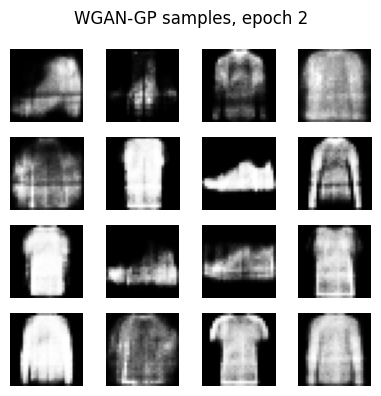

[WGAN-GP] Epoch [3/10] Step [100/3750] C_loss: -2.8355 | G_loss: -2.2513
[WGAN-GP] Epoch [3/10] Step [200/3750] C_loss: -2.1423 | G_loss: 1.8986
[WGAN-GP] Epoch [3/10] Step [300/3750] C_loss: -1.5718 | G_loss: 0.0479
[WGAN-GP] Epoch [3/10] Step [400/3750] C_loss: -1.9335 | G_loss: -1.2198
[WGAN-GP] Epoch [3/10] Step [500/3750] C_loss: -1.4580 | G_loss: -2.2062
[WGAN-GP] Epoch [3/10] Step [600/3750] C_loss: -1.6191 | G_loss: 1.3068
[WGAN-GP] Epoch [3/10] Step [700/3750] C_loss: -2.4805 | G_loss: 1.1127
[WGAN-GP] Epoch [3/10] Step [800/3750] C_loss: -2.0487 | G_loss: 1.1046
[WGAN-GP] Epoch [3/10] Step [900/3750] C_loss: -2.1664 | G_loss: 0.8225
[WGAN-GP] Epoch [3/10] Step [1000/3750] C_loss: -2.3247 | G_loss: 1.4614
[WGAN-GP] Epoch [3/10] Step [1100/3750] C_loss: -2.7143 | G_loss: 3.7319
[WGAN-GP] Epoch [3/10] Step [1200/3750] C_loss: -1.8807 | G_loss: -1.3522
[WGAN-GP] Epoch [3/10] Step [1300/3750] C_loss: -1.8058 | G_loss: 1.0862
[WGAN-GP] Epoch [3/10] Step [1400/3750] C_loss: -2.6838 

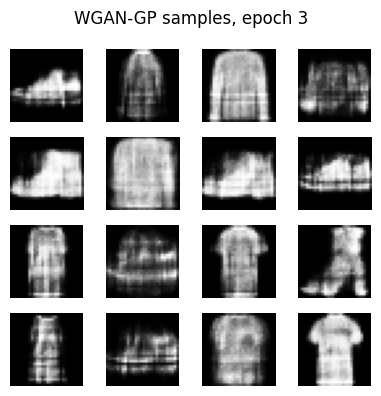

[WGAN-GP] Epoch [4/10] Step [100/3750] C_loss: -2.3101 | G_loss: 2.4371
[WGAN-GP] Epoch [4/10] Step [200/3750] C_loss: -1.6376 | G_loss: 1.6814
[WGAN-GP] Epoch [4/10] Step [300/3750] C_loss: -1.7755 | G_loss: 0.6441
[WGAN-GP] Epoch [4/10] Step [400/3750] C_loss: -1.3724 | G_loss: 1.3916
[WGAN-GP] Epoch [4/10] Step [500/3750] C_loss: -1.8554 | G_loss: 1.1806
[WGAN-GP] Epoch [4/10] Step [600/3750] C_loss: -2.5901 | G_loss: 3.8717
[WGAN-GP] Epoch [4/10] Step [700/3750] C_loss: -2.6027 | G_loss: 3.2753
[WGAN-GP] Epoch [4/10] Step [800/3750] C_loss: -1.5610 | G_loss: 1.5027
[WGAN-GP] Epoch [4/10] Step [900/3750] C_loss: -1.6591 | G_loss: 1.2675
[WGAN-GP] Epoch [4/10] Step [1000/3750] C_loss: -1.9582 | G_loss: 1.4512
[WGAN-GP] Epoch [4/10] Step [1100/3750] C_loss: -1.4140 | G_loss: 2.2771
[WGAN-GP] Epoch [4/10] Step [1200/3750] C_loss: -1.7801 | G_loss: -0.1920
[WGAN-GP] Epoch [4/10] Step [1300/3750] C_loss: -1.6389 | G_loss: 0.3146
[WGAN-GP] Epoch [4/10] Step [1400/3750] C_loss: -1.4302 | G

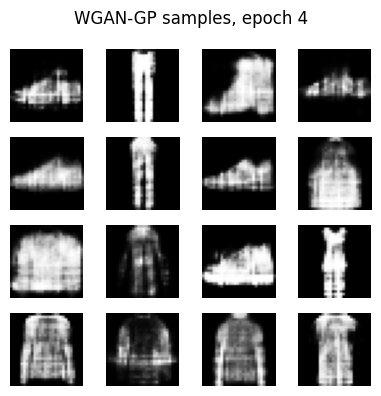

[WGAN-GP] Epoch [5/10] Step [100/3750] C_loss: -1.4380 | G_loss: 2.6626
[WGAN-GP] Epoch [5/10] Step [200/3750] C_loss: -1.1788 | G_loss: 2.6609
[WGAN-GP] Epoch [5/10] Step [300/3750] C_loss: -1.3392 | G_loss: 0.8906
[WGAN-GP] Epoch [5/10] Step [400/3750] C_loss: -1.0472 | G_loss: 2.9098
[WGAN-GP] Epoch [5/10] Step [500/3750] C_loss: -1.6904 | G_loss: 2.1602
[WGAN-GP] Epoch [5/10] Step [600/3750] C_loss: -1.7782 | G_loss: 0.8761
[WGAN-GP] Epoch [5/10] Step [700/3750] C_loss: -1.8137 | G_loss: -1.5325
[WGAN-GP] Epoch [5/10] Step [800/3750] C_loss: -1.4437 | G_loss: -0.8266
[WGAN-GP] Epoch [5/10] Step [900/3750] C_loss: -1.2702 | G_loss: 3.1529
[WGAN-GP] Epoch [5/10] Step [1000/3750] C_loss: -1.7665 | G_loss: 2.0648
[WGAN-GP] Epoch [5/10] Step [1100/3750] C_loss: -1.4827 | G_loss: 0.3518
[WGAN-GP] Epoch [5/10] Step [1200/3750] C_loss: -1.7975 | G_loss: 2.6879
[WGAN-GP] Epoch [5/10] Step [1300/3750] C_loss: -1.6750 | G_loss: 1.5197
[WGAN-GP] Epoch [5/10] Step [1400/3750] C_loss: -1.6948 | 

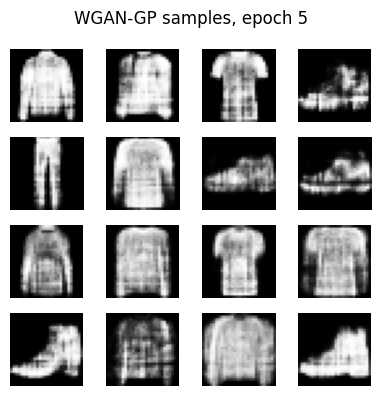

[WGAN-GP] Epoch [6/10] Step [100/3750] C_loss: -1.5137 | G_loss: 3.1139
[WGAN-GP] Epoch [6/10] Step [200/3750] C_loss: -2.4431 | G_loss: 1.1434
[WGAN-GP] Epoch [6/10] Step [300/3750] C_loss: -1.2252 | G_loss: 1.3309
[WGAN-GP] Epoch [6/10] Step [400/3750] C_loss: -1.4147 | G_loss: -0.6891
[WGAN-GP] Epoch [6/10] Step [500/3750] C_loss: -1.7738 | G_loss: 2.4604
[WGAN-GP] Epoch [6/10] Step [600/3750] C_loss: -1.7977 | G_loss: 3.4070
[WGAN-GP] Epoch [6/10] Step [700/3750] C_loss: -1.1256 | G_loss: 2.7919
[WGAN-GP] Epoch [6/10] Step [800/3750] C_loss: -1.7877 | G_loss: 2.5668
[WGAN-GP] Epoch [6/10] Step [900/3750] C_loss: -1.0237 | G_loss: -1.6035
[WGAN-GP] Epoch [6/10] Step [1000/3750] C_loss: -2.5581 | G_loss: 2.3284
[WGAN-GP] Epoch [6/10] Step [1100/3750] C_loss: -0.9608 | G_loss: 3.3398
[WGAN-GP] Epoch [6/10] Step [1200/3750] C_loss: -1.8436 | G_loss: -0.7986
[WGAN-GP] Epoch [6/10] Step [1300/3750] C_loss: -1.2956 | G_loss: -0.5610
[WGAN-GP] Epoch [6/10] Step [1400/3750] C_loss: -2.4249 

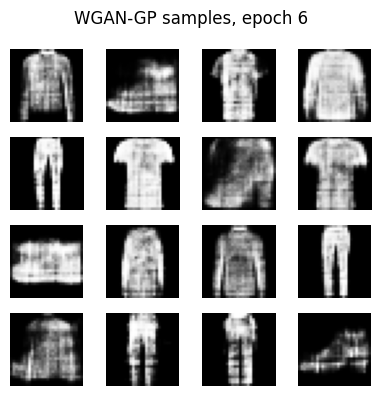

[WGAN-GP] Epoch [7/10] Step [100/3750] C_loss: -1.3231 | G_loss: 1.7850
[WGAN-GP] Epoch [7/10] Step [200/3750] C_loss: -1.0169 | G_loss: 1.7134
[WGAN-GP] Epoch [7/10] Step [300/3750] C_loss: -1.1051 | G_loss: 0.8235
[WGAN-GP] Epoch [7/10] Step [400/3750] C_loss: -1.8578 | G_loss: 1.8286
[WGAN-GP] Epoch [7/10] Step [500/3750] C_loss: -1.2405 | G_loss: 0.5358
[WGAN-GP] Epoch [7/10] Step [600/3750] C_loss: -1.8853 | G_loss: 0.0970
[WGAN-GP] Epoch [7/10] Step [700/3750] C_loss: -2.2112 | G_loss: 0.4745
[WGAN-GP] Epoch [7/10] Step [800/3750] C_loss: -0.9794 | G_loss: 3.1607
[WGAN-GP] Epoch [7/10] Step [900/3750] C_loss: -1.2686 | G_loss: 2.5549
[WGAN-GP] Epoch [7/10] Step [1000/3750] C_loss: -1.6668 | G_loss: 1.8550
[WGAN-GP] Epoch [7/10] Step [1100/3750] C_loss: -1.0988 | G_loss: 1.9285
[WGAN-GP] Epoch [7/10] Step [1200/3750] C_loss: -1.5533 | G_loss: 2.9410
[WGAN-GP] Epoch [7/10] Step [1300/3750] C_loss: -1.8001 | G_loss: 1.4813
[WGAN-GP] Epoch [7/10] Step [1400/3750] C_loss: -1.2762 | G_

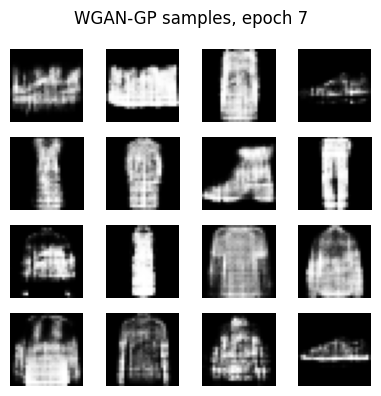

[WGAN-GP] Epoch [8/10] Step [100/3750] C_loss: -1.6133 | G_loss: 0.9142
[WGAN-GP] Epoch [8/10] Step [200/3750] C_loss: -1.2532 | G_loss: 1.3952
[WGAN-GP] Epoch [8/10] Step [300/3750] C_loss: -1.6928 | G_loss: 1.7355
[WGAN-GP] Epoch [8/10] Step [400/3750] C_loss: -1.2565 | G_loss: 1.5369
[WGAN-GP] Epoch [8/10] Step [500/3750] C_loss: -1.3720 | G_loss: 0.4853
[WGAN-GP] Epoch [8/10] Step [600/3750] C_loss: -1.5424 | G_loss: 1.3321
[WGAN-GP] Epoch [8/10] Step [700/3750] C_loss: -2.0232 | G_loss: 3.2726
[WGAN-GP] Epoch [8/10] Step [800/3750] C_loss: -1.3278 | G_loss: 1.3238
[WGAN-GP] Epoch [8/10] Step [900/3750] C_loss: 0.7266 | G_loss: -0.7188
[WGAN-GP] Epoch [8/10] Step [1000/3750] C_loss: -1.4375 | G_loss: 1.3961
[WGAN-GP] Epoch [8/10] Step [1100/3750] C_loss: -1.5314 | G_loss: 0.7814
[WGAN-GP] Epoch [8/10] Step [1200/3750] C_loss: -2.4473 | G_loss: -1.3147
[WGAN-GP] Epoch [8/10] Step [1300/3750] C_loss: -0.5113 | G_loss: 1.3392
[WGAN-GP] Epoch [8/10] Step [1400/3750] C_loss: -0.8390 | G

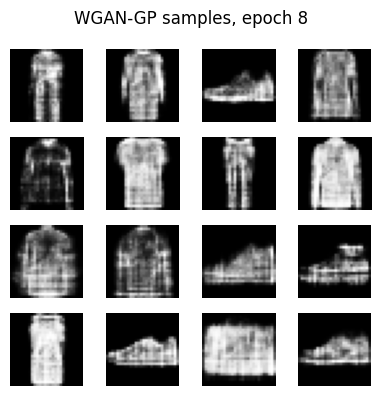

[WGAN-GP] Epoch [9/10] Step [100/3750] C_loss: -0.9439 | G_loss: 0.7995
[WGAN-GP] Epoch [9/10] Step [200/3750] C_loss: -1.4945 | G_loss: -1.3051
[WGAN-GP] Epoch [9/10] Step [300/3750] C_loss: -1.1301 | G_loss: 1.0497
[WGAN-GP] Epoch [9/10] Step [400/3750] C_loss: -1.7755 | G_loss: 1.8597
[WGAN-GP] Epoch [9/10] Step [500/3750] C_loss: -1.4725 | G_loss: -0.8014
[WGAN-GP] Epoch [9/10] Step [600/3750] C_loss: -1.5141 | G_loss: -0.1925
[WGAN-GP] Epoch [9/10] Step [700/3750] C_loss: -0.8834 | G_loss: 0.8570
[WGAN-GP] Epoch [9/10] Step [800/3750] C_loss: -0.9698 | G_loss: 2.2189
[WGAN-GP] Epoch [9/10] Step [900/3750] C_loss: -0.6825 | G_loss: 1.2793
[WGAN-GP] Epoch [9/10] Step [1000/3750] C_loss: -1.3098 | G_loss: -0.7994
[WGAN-GP] Epoch [9/10] Step [1100/3750] C_loss: -1.0665 | G_loss: 4.4008
[WGAN-GP] Epoch [9/10] Step [1200/3750] C_loss: -1.2163 | G_loss: -0.6785
[WGAN-GP] Epoch [9/10] Step [1300/3750] C_loss: -1.0944 | G_loss: 1.5170
[WGAN-GP] Epoch [9/10] Step [1400/3750] C_loss: -0.5356

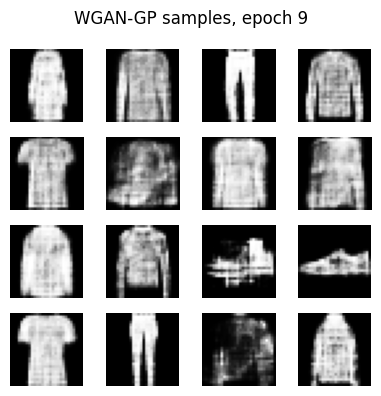

[WGAN-GP] Epoch [10/10] Step [100/3750] C_loss: -1.1451 | G_loss: 2.4200
[WGAN-GP] Epoch [10/10] Step [200/3750] C_loss: -1.3598 | G_loss: 0.5729
[WGAN-GP] Epoch [10/10] Step [300/3750] C_loss: -1.3647 | G_loss: 3.2366
[WGAN-GP] Epoch [10/10] Step [400/3750] C_loss: -0.8163 | G_loss: 1.6004
[WGAN-GP] Epoch [10/10] Step [500/3750] C_loss: -1.3440 | G_loss: 2.5739
[WGAN-GP] Epoch [10/10] Step [600/3750] C_loss: -1.9084 | G_loss: 1.1763
[WGAN-GP] Epoch [10/10] Step [700/3750] C_loss: -3.1056 | G_loss: 3.1190
[WGAN-GP] Epoch [10/10] Step [800/3750] C_loss: -1.3833 | G_loss: 1.6467
[WGAN-GP] Epoch [10/10] Step [900/3750] C_loss: -0.9742 | G_loss: 1.3347
[WGAN-GP] Epoch [10/10] Step [1000/3750] C_loss: -1.2270 | G_loss: 0.5299
[WGAN-GP] Epoch [10/10] Step [1100/3750] C_loss: -1.6798 | G_loss: 1.5471
[WGAN-GP] Epoch [10/10] Step [1200/3750] C_loss: -1.4229 | G_loss: 1.5955
[WGAN-GP] Epoch [10/10] Step [1300/3750] C_loss: -0.9748 | G_loss: 1.2179
[WGAN-GP] Epoch [10/10] Step [1400/3750] C_loss

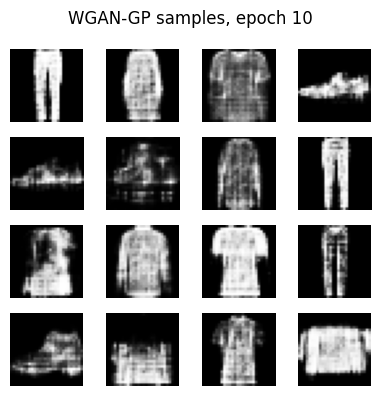

In [39]:
G_losses_gp = []
C_losses_gp = []

for epoch in range(config_gp.num_epochs):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # === Обучаем критик несколько раз ===
        for _ in range(config_gp.n_critic):
            C_gp.zero_grad()

            # реальные
            real_scores = C_gp(real_imgs)
            loss_real = -real_scores.mean()

            # фейковые
            z = torch.randn(batch_size, config_gp.noise_size, device=device)
            fake_imgs = G_gp(z).detach()
            fake_scores = C_gp(fake_imgs)
            loss_fake = fake_scores.mean()

            # GP
            gp = gradient_penalty(C_gp, real_imgs, fake_imgs)

            loss_C = loss_real + loss_fake + config_gp.lambda_gp * gp
            loss_C.backward()
            opt_C_gp.step()

        # === Обучаем генератор ===
        G_gp.zero_grad()
        z = torch.randn(batch_size, config_gp.noise_size, device=device)
        fake_imgs = G_gp(z)
        fake_scores = C_gp(fake_imgs)
        loss_G = -fake_scores.mean()
        loss_G.backward()
        opt_G_gp.step()

        G_losses_gp.append(loss_G.item())
        C_losses_gp.append(loss_C.item())

        if (i + 1) % config_gp.print_freq == 0:
            print(
                f"[WGAN-GP] Epoch [{epoch+1}/{config_gp.num_epochs}] "
                f"Step [{i+1}/{len(dataloader)}] "
                f"C_loss: {loss_C.item():.4f} | G_loss: {loss_G.item():.4f}"
            )

    # Сэмплы после каждой эпохи
    with torch.no_grad():
        z = torch.randn(16, config_gp.noise_size, device=device)
        fake_sample = G_gp(z).cpu()

        plt.figure(figsize=(4, 4))
        for k in range(16):
            plt.subplot(4, 4, k+1)
            plt.imshow(fake_sample[k, 0], cmap="gray")
            plt.axis("off")
        plt.suptitle(f"WGAN-GP samples, epoch {epoch+1}")
        plt.tight_layout()
        plt.show()


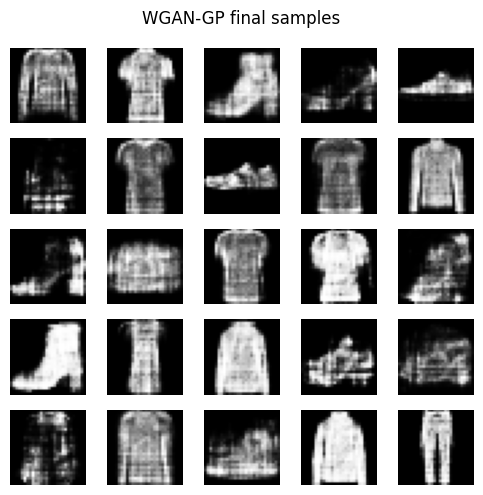

In [40]:
with torch.no_grad():
    z = torch.randn(25, config_gp.noise_size, device=device)
    fake_final_gp = G_gp(z).cpu()

plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(fake_final_gp[i,0], cmap="gray")
    plt.axis("off")
plt.suptitle("WGAN-GP final samples")
plt.tight_layout()
plt.show()

После замены weight clipping на gradient penalty заметно улучшилась стабильность обучения и качество сгенерированных изображений.
Сгенерированные изображения стали более чёткие, лучше различаются разные элементы одежды, артефактов меньше

Условный WGAN-GP (cWGAN-GP) + условная генерация

In [42]:
class ConfigCond:
    pass

config_c = ConfigCond()
config_c.batch_size = 64
config_c.num_epochs = 10
config_c.noise_size = 50
config_c.n_critic = 5
config_c.lambda_gp = 10.0
config_c.print_freq = 100


In [45]:
num_classes = 10

In [43]:
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes=num_classes).float()

In [ ]:
class GeneratorCond(nn.Module):
    def __init__(self, noise_dim=50, num_classes=10):
        super().__init__()
        self.noise_dim = noise_dim
        self.num_classes = num_classes
        in_dim = noise_dim + num_classes
        self.model = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 28*28),
            nn.Sigmoid()
        )

    def forward(self, z, y_onehot):
        # z: (B, noise_dim), y_onehot: (B, num_classes)
        x = torch.cat([z, y_onehot], dim=1)
        out = self.model(x)
        return out.view(-1, 1, 28, 28)

class CriticCond(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        in_dim = 28*28 + num_classes
        self.model = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LayerNorm(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, img, y_onehot):
        # img: (B,1,28,28)
        x = img.view(img.size(0), -1)
        x = torch.cat([x, y_onehot], dim=1)
        return self.model(x)

G_c = GeneratorCond(config_c.noise_size, num_classes).to(device)
C_c = CriticCond(num_classes).to(device)

opt_G_c = optim.Adam(G_c.parameters(), lr=1e-4, betas=(0.5, 0.9))
opt_C_c = optim.Adam(C_c.parameters(), lr=1e-4, betas=(0.5, 0.9))

In [48]:
def gradient_penalty_cond(critic, real_imgs, fake_imgs, y_onehot):
    batch_size = real_imgs.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real_imgs)

    interpolates = (alpha * real_imgs + (1 - alpha) * fake_imgs).requires_grad_(True)
    critic_interpolates = critic(interpolates, y_onehot)
    ones = torch.ones_like(critic_interpolates, device=device)

    gradients = grad(
        outputs=critic_interpolates,
        inputs=interpolates,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    grad_norm = gradients.norm(2, dim=1)
    gp = ((grad_norm - 1.0) ** 2).mean()
    return gp

[cWGAN-GP] Epoch [1/10] Step [100/3750] C_loss: -6.9791 | G_loss: 5.9060
[cWGAN-GP] Epoch [1/10] Step [200/3750] C_loss: -4.2218 | G_loss: 4.0378
[cWGAN-GP] Epoch [1/10] Step [300/3750] C_loss: -5.6049 | G_loss: 7.0582
[cWGAN-GP] Epoch [1/10] Step [400/3750] C_loss: -6.5365 | G_loss: 8.5251
[cWGAN-GP] Epoch [1/10] Step [500/3750] C_loss: -7.6518 | G_loss: 10.2667
[cWGAN-GP] Epoch [1/10] Step [600/3750] C_loss: -6.9734 | G_loss: 11.3426
[cWGAN-GP] Epoch [1/10] Step [700/3750] C_loss: -7.1108 | G_loss: 12.2522
[cWGAN-GP] Epoch [1/10] Step [800/3750] C_loss: -6.8911 | G_loss: 13.2756
[cWGAN-GP] Epoch [1/10] Step [900/3750] C_loss: -6.9309 | G_loss: 13.7178
[cWGAN-GP] Epoch [1/10] Step [1000/3750] C_loss: -5.9012 | G_loss: 13.6837
[cWGAN-GP] Epoch [1/10] Step [1100/3750] C_loss: -5.9400 | G_loss: 12.2539
[cWGAN-GP] Epoch [1/10] Step [1200/3750] C_loss: -5.3158 | G_loss: 13.9404
[cWGAN-GP] Epoch [1/10] Step [1300/3750] C_loss: -5.6452 | G_loss: 14.2648
[cWGAN-GP] Epoch [1/10] Step [1400/375

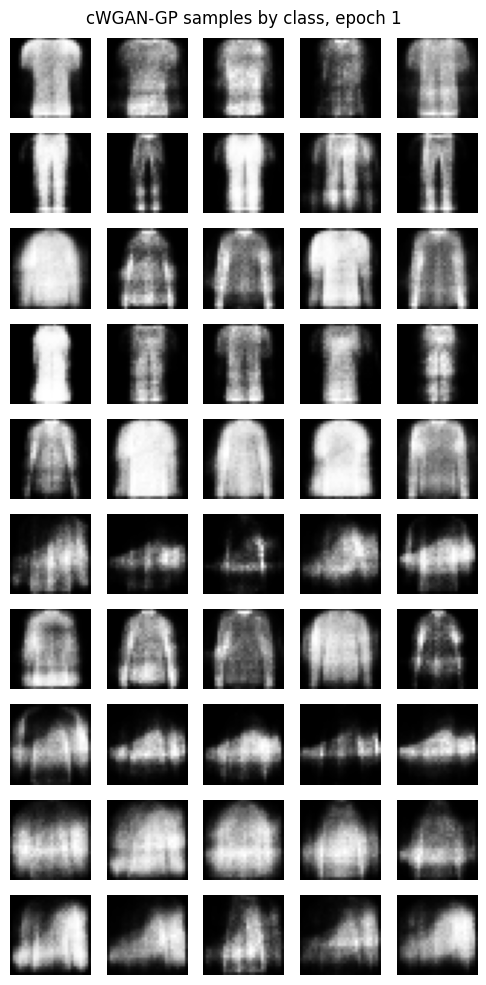

[cWGAN-GP] Epoch [2/10] Step [100/3750] C_loss: -2.7260 | G_loss: 15.3146
[cWGAN-GP] Epoch [2/10] Step [200/3750] C_loss: -3.1183 | G_loss: 13.6402
[cWGAN-GP] Epoch [2/10] Step [300/3750] C_loss: -3.3197 | G_loss: 14.3226
[cWGAN-GP] Epoch [2/10] Step [400/3750] C_loss: -3.2810 | G_loss: 14.3187
[cWGAN-GP] Epoch [2/10] Step [500/3750] C_loss: -3.3558 | G_loss: 16.6235
[cWGAN-GP] Epoch [2/10] Step [600/3750] C_loss: -3.1948 | G_loss: 16.5858
[cWGAN-GP] Epoch [2/10] Step [700/3750] C_loss: -3.0381 | G_loss: 15.0628
[cWGAN-GP] Epoch [2/10] Step [800/3750] C_loss: -3.3673 | G_loss: 13.5269
[cWGAN-GP] Epoch [2/10] Step [900/3750] C_loss: -3.5485 | G_loss: 15.1624
[cWGAN-GP] Epoch [2/10] Step [1000/3750] C_loss: -3.7654 | G_loss: 15.5787
[cWGAN-GP] Epoch [2/10] Step [1100/3750] C_loss: -2.8221 | G_loss: 15.4403
[cWGAN-GP] Epoch [2/10] Step [1200/3750] C_loss: -3.3741 | G_loss: 13.9817
[cWGAN-GP] Epoch [2/10] Step [1300/3750] C_loss: -3.4997 | G_loss: 14.1817
[cWGAN-GP] Epoch [2/10] Step [1400

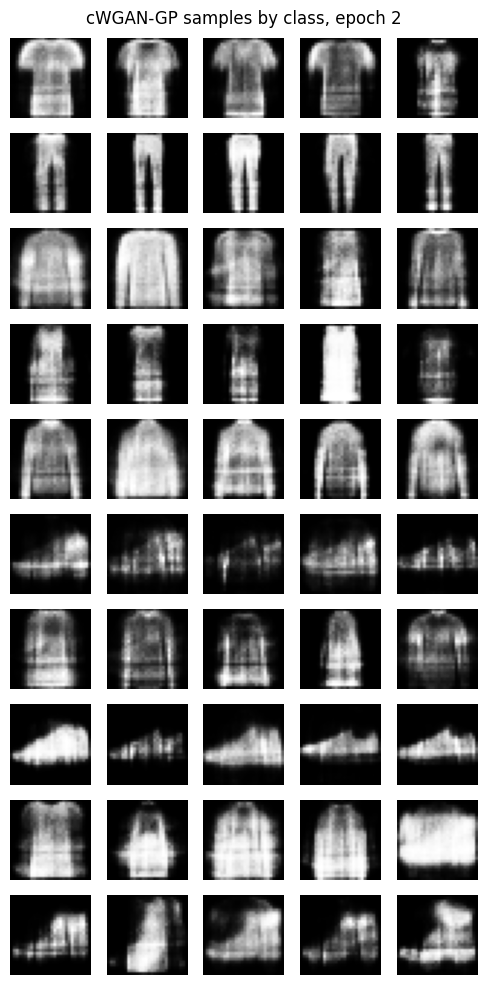

[cWGAN-GP] Epoch [3/10] Step [100/3750] C_loss: -2.6672 | G_loss: 14.1491
[cWGAN-GP] Epoch [3/10] Step [200/3750] C_loss: -2.3705 | G_loss: 12.5841
[cWGAN-GP] Epoch [3/10] Step [300/3750] C_loss: -2.8222 | G_loss: 14.1171
[cWGAN-GP] Epoch [3/10] Step [400/3750] C_loss: -2.3741 | G_loss: 13.1134
[cWGAN-GP] Epoch [3/10] Step [500/3750] C_loss: -2.8369 | G_loss: 13.3610
[cWGAN-GP] Epoch [3/10] Step [600/3750] C_loss: -2.5360 | G_loss: 13.0575
[cWGAN-GP] Epoch [3/10] Step [700/3750] C_loss: -2.5974 | G_loss: 13.7775
[cWGAN-GP] Epoch [3/10] Step [800/3750] C_loss: -2.2475 | G_loss: 14.9539
[cWGAN-GP] Epoch [3/10] Step [900/3750] C_loss: -2.7461 | G_loss: 12.7891
[cWGAN-GP] Epoch [3/10] Step [1000/3750] C_loss: -2.9200 | G_loss: 12.9365
[cWGAN-GP] Epoch [3/10] Step [1100/3750] C_loss: -2.2827 | G_loss: 13.4865
[cWGAN-GP] Epoch [3/10] Step [1200/3750] C_loss: -2.2386 | G_loss: 13.6260
[cWGAN-GP] Epoch [3/10] Step [1300/3750] C_loss: -2.4583 | G_loss: 13.1710
[cWGAN-GP] Epoch [3/10] Step [1400

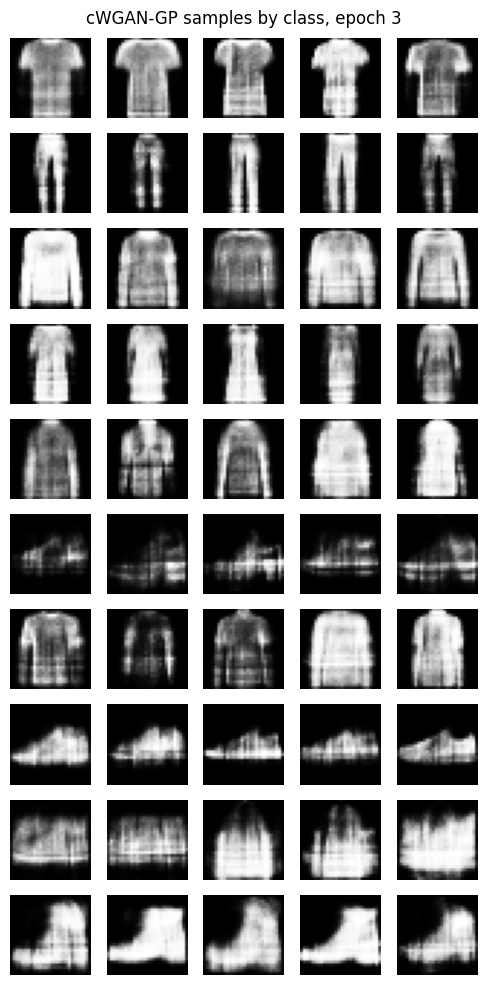

[cWGAN-GP] Epoch [4/10] Step [100/3750] C_loss: -2.7952 | G_loss: 12.6200
[cWGAN-GP] Epoch [4/10] Step [200/3750] C_loss: -2.2937 | G_loss: 13.4666
[cWGAN-GP] Epoch [4/10] Step [300/3750] C_loss: -1.9340 | G_loss: 12.5139
[cWGAN-GP] Epoch [4/10] Step [400/3750] C_loss: -1.9866 | G_loss: 12.4091
[cWGAN-GP] Epoch [4/10] Step [500/3750] C_loss: -2.1802 | G_loss: 11.7267
[cWGAN-GP] Epoch [4/10] Step [600/3750] C_loss: -2.4019 | G_loss: 11.2643
[cWGAN-GP] Epoch [4/10] Step [700/3750] C_loss: -2.1472 | G_loss: 12.4887
[cWGAN-GP] Epoch [4/10] Step [800/3750] C_loss: -1.9190 | G_loss: 12.5139
[cWGAN-GP] Epoch [4/10] Step [900/3750] C_loss: -2.6862 | G_loss: 13.2549
[cWGAN-GP] Epoch [4/10] Step [1000/3750] C_loss: -2.1065 | G_loss: 12.2571
[cWGAN-GP] Epoch [4/10] Step [1100/3750] C_loss: -2.6068 | G_loss: 12.8299
[cWGAN-GP] Epoch [4/10] Step [1200/3750] C_loss: -2.2752 | G_loss: 12.7995
[cWGAN-GP] Epoch [4/10] Step [1300/3750] C_loss: -2.6338 | G_loss: 12.5469
[cWGAN-GP] Epoch [4/10] Step [1400

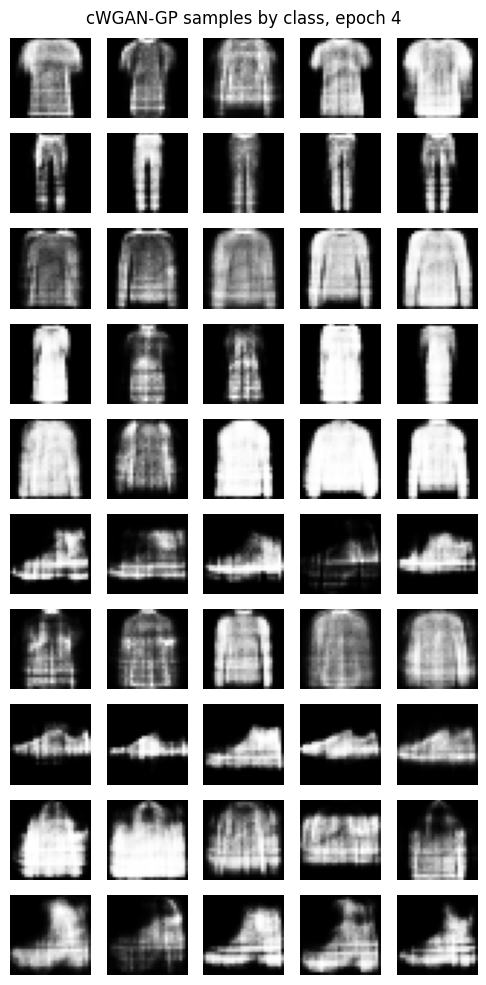

[cWGAN-GP] Epoch [5/10] Step [100/3750] C_loss: -2.1348 | G_loss: 11.9090
[cWGAN-GP] Epoch [5/10] Step [200/3750] C_loss: -1.8899 | G_loss: 13.0325
[cWGAN-GP] Epoch [5/10] Step [300/3750] C_loss: -2.1647 | G_loss: 13.0196
[cWGAN-GP] Epoch [5/10] Step [400/3750] C_loss: -1.6984 | G_loss: 14.2614
[cWGAN-GP] Epoch [5/10] Step [500/3750] C_loss: -1.7351 | G_loss: 13.5817
[cWGAN-GP] Epoch [5/10] Step [600/3750] C_loss: -2.0109 | G_loss: 12.6054
[cWGAN-GP] Epoch [5/10] Step [700/3750] C_loss: -1.9363 | G_loss: 13.6866
[cWGAN-GP] Epoch [5/10] Step [800/3750] C_loss: -1.8815 | G_loss: 11.8359
[cWGAN-GP] Epoch [5/10] Step [900/3750] C_loss: -2.2071 | G_loss: 12.9908
[cWGAN-GP] Epoch [5/10] Step [1000/3750] C_loss: -2.1586 | G_loss: 13.2517
[cWGAN-GP] Epoch [5/10] Step [1100/3750] C_loss: -1.7880 | G_loss: 12.5642
[cWGAN-GP] Epoch [5/10] Step [1200/3750] C_loss: -2.2718 | G_loss: 12.6623
[cWGAN-GP] Epoch [5/10] Step [1300/3750] C_loss: -1.5429 | G_loss: 12.8150
[cWGAN-GP] Epoch [5/10] Step [1400

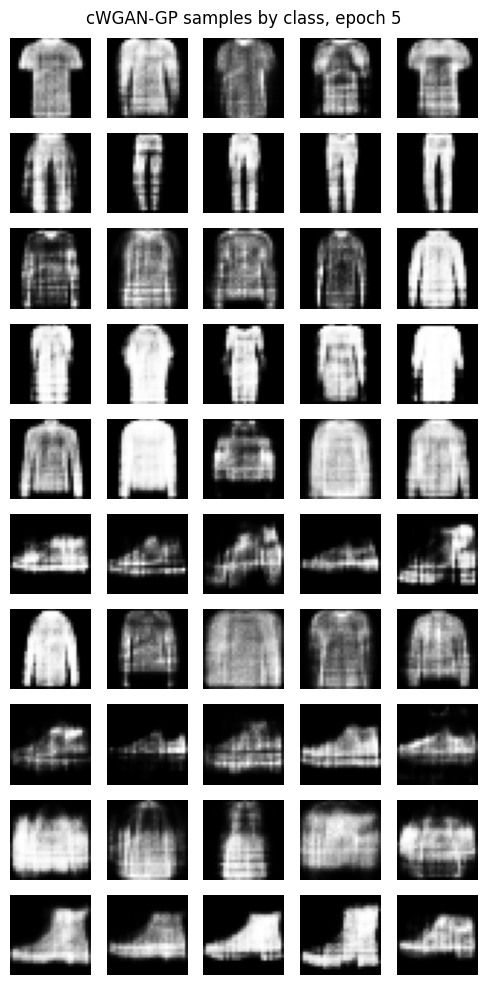

[cWGAN-GP] Epoch [6/10] Step [100/3750] C_loss: -1.4887 | G_loss: 12.8332
[cWGAN-GP] Epoch [6/10] Step [200/3750] C_loss: -2.1130 | G_loss: 12.2092
[cWGAN-GP] Epoch [6/10] Step [300/3750] C_loss: -2.0218 | G_loss: 12.2272
[cWGAN-GP] Epoch [6/10] Step [400/3750] C_loss: -2.1263 | G_loss: 12.4343
[cWGAN-GP] Epoch [6/10] Step [500/3750] C_loss: -2.0164 | G_loss: 11.9097
[cWGAN-GP] Epoch [6/10] Step [600/3750] C_loss: -2.0121 | G_loss: 12.4140
[cWGAN-GP] Epoch [6/10] Step [700/3750] C_loss: -2.2421 | G_loss: 13.8997
[cWGAN-GP] Epoch [6/10] Step [800/3750] C_loss: -2.3557 | G_loss: 11.8119
[cWGAN-GP] Epoch [6/10] Step [900/3750] C_loss: -1.4659 | G_loss: 12.7130
[cWGAN-GP] Epoch [6/10] Step [1000/3750] C_loss: -1.9257 | G_loss: 12.0512
[cWGAN-GP] Epoch [6/10] Step [1100/3750] C_loss: -2.2982 | G_loss: 13.4347
[cWGAN-GP] Epoch [6/10] Step [1200/3750] C_loss: -1.6448 | G_loss: 12.4672
[cWGAN-GP] Epoch [6/10] Step [1300/3750] C_loss: -2.2494 | G_loss: 13.3041
[cWGAN-GP] Epoch [6/10] Step [1400

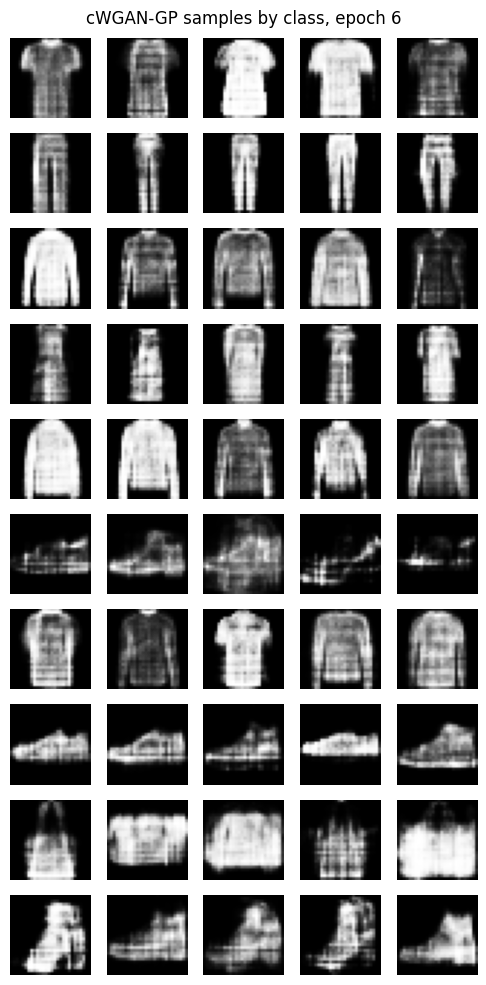

[cWGAN-GP] Epoch [7/10] Step [100/3750] C_loss: -1.5430 | G_loss: 12.8461
[cWGAN-GP] Epoch [7/10] Step [200/3750] C_loss: -1.9327 | G_loss: 12.6408
[cWGAN-GP] Epoch [7/10] Step [300/3750] C_loss: -1.6212 | G_loss: 12.4499
[cWGAN-GP] Epoch [7/10] Step [400/3750] C_loss: -2.3946 | G_loss: 10.5178
[cWGAN-GP] Epoch [7/10] Step [500/3750] C_loss: -1.7470 | G_loss: 13.5879
[cWGAN-GP] Epoch [7/10] Step [600/3750] C_loss: -1.5063 | G_loss: 11.6733
[cWGAN-GP] Epoch [7/10] Step [700/3750] C_loss: -1.9375 | G_loss: 12.6494
[cWGAN-GP] Epoch [7/10] Step [800/3750] C_loss: -1.8776 | G_loss: 13.1547
[cWGAN-GP] Epoch [7/10] Step [900/3750] C_loss: -1.1860 | G_loss: 12.6726
[cWGAN-GP] Epoch [7/10] Step [1000/3750] C_loss: -2.0057 | G_loss: 12.7312
[cWGAN-GP] Epoch [7/10] Step [1100/3750] C_loss: -1.3606 | G_loss: 12.6379
[cWGAN-GP] Epoch [7/10] Step [1200/3750] C_loss: -1.8544 | G_loss: 13.0454
[cWGAN-GP] Epoch [7/10] Step [1300/3750] C_loss: -1.6154 | G_loss: 13.2759
[cWGAN-GP] Epoch [7/10] Step [1400

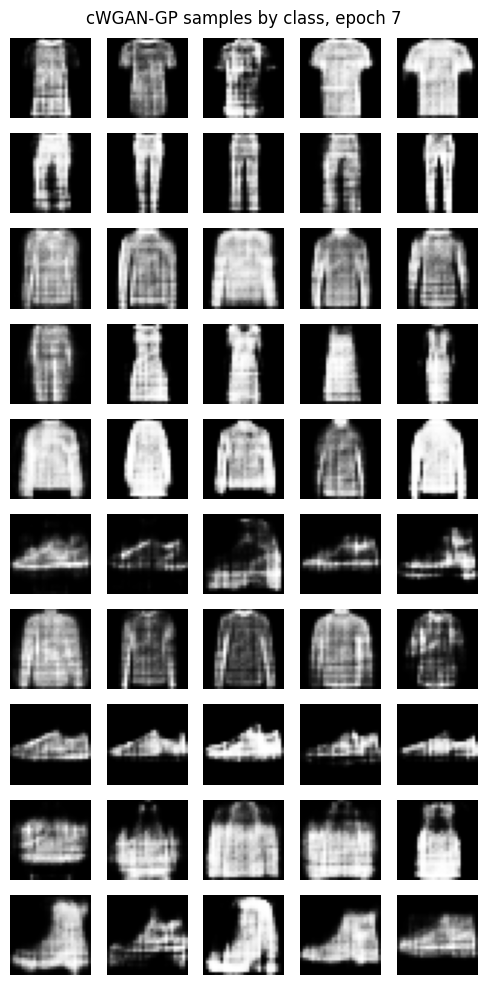

[cWGAN-GP] Epoch [8/10] Step [100/3750] C_loss: -1.1100 | G_loss: 12.9945
[cWGAN-GP] Epoch [8/10] Step [200/3750] C_loss: -1.3858 | G_loss: 13.3372
[cWGAN-GP] Epoch [8/10] Step [300/3750] C_loss: -1.2263 | G_loss: 12.4596
[cWGAN-GP] Epoch [8/10] Step [400/3750] C_loss: -1.5715 | G_loss: 12.6439
[cWGAN-GP] Epoch [8/10] Step [500/3750] C_loss: -1.7659 | G_loss: 12.5093
[cWGAN-GP] Epoch [8/10] Step [600/3750] C_loss: -1.7266 | G_loss: 13.5963
[cWGAN-GP] Epoch [8/10] Step [700/3750] C_loss: -1.3235 | G_loss: 13.8245
[cWGAN-GP] Epoch [8/10] Step [800/3750] C_loss: -1.6859 | G_loss: 13.3240
[cWGAN-GP] Epoch [8/10] Step [900/3750] C_loss: -1.7904 | G_loss: 11.4186
[cWGAN-GP] Epoch [8/10] Step [1000/3750] C_loss: -1.4999 | G_loss: 12.3403
[cWGAN-GP] Epoch [8/10] Step [1100/3750] C_loss: -1.6058 | G_loss: 12.9451
[cWGAN-GP] Epoch [8/10] Step [1200/3750] C_loss: -1.4959 | G_loss: 12.2609
[cWGAN-GP] Epoch [8/10] Step [1300/3750] C_loss: -1.9017 | G_loss: 12.8208
[cWGAN-GP] Epoch [8/10] Step [1400

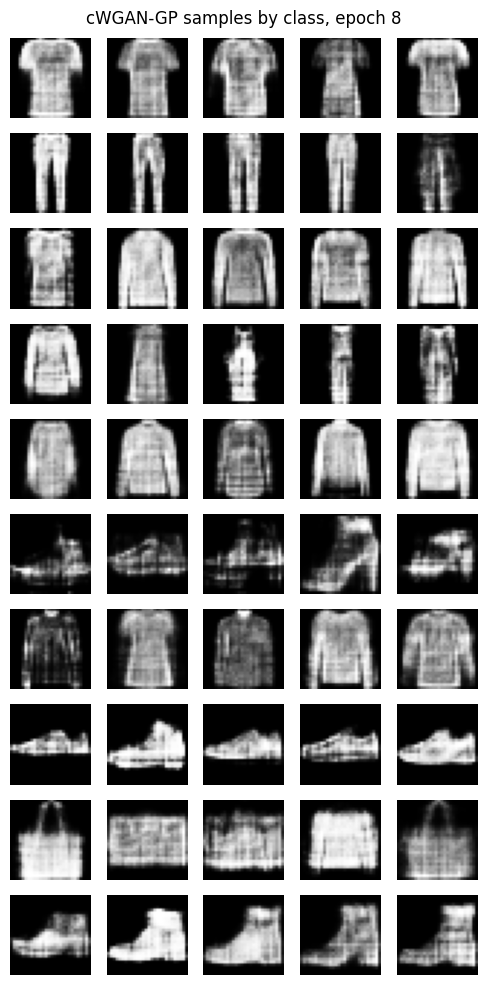

[cWGAN-GP] Epoch [9/10] Step [100/3750] C_loss: -1.7603 | G_loss: 13.5907
[cWGAN-GP] Epoch [9/10] Step [200/3750] C_loss: -1.3032 | G_loss: 12.9479
[cWGAN-GP] Epoch [9/10] Step [300/3750] C_loss: -1.0353 | G_loss: 12.1513
[cWGAN-GP] Epoch [9/10] Step [400/3750] C_loss: -1.0373 | G_loss: 14.3546
[cWGAN-GP] Epoch [9/10] Step [500/3750] C_loss: -1.3100 | G_loss: 13.1186
[cWGAN-GP] Epoch [9/10] Step [600/3750] C_loss: -1.4859 | G_loss: 13.4271
[cWGAN-GP] Epoch [9/10] Step [700/3750] C_loss: -1.7578 | G_loss: 14.0376
[cWGAN-GP] Epoch [9/10] Step [800/3750] C_loss: -1.0059 | G_loss: 13.8661
[cWGAN-GP] Epoch [9/10] Step [900/3750] C_loss: -1.6413 | G_loss: 12.3955
[cWGAN-GP] Epoch [9/10] Step [1000/3750] C_loss: -2.2242 | G_loss: 12.7193
[cWGAN-GP] Epoch [9/10] Step [1100/3750] C_loss: -1.5976 | G_loss: 14.0590
[cWGAN-GP] Epoch [9/10] Step [1200/3750] C_loss: -1.3535 | G_loss: 12.4413
[cWGAN-GP] Epoch [9/10] Step [1300/3750] C_loss: -1.2152 | G_loss: 13.2734
[cWGAN-GP] Epoch [9/10] Step [1400

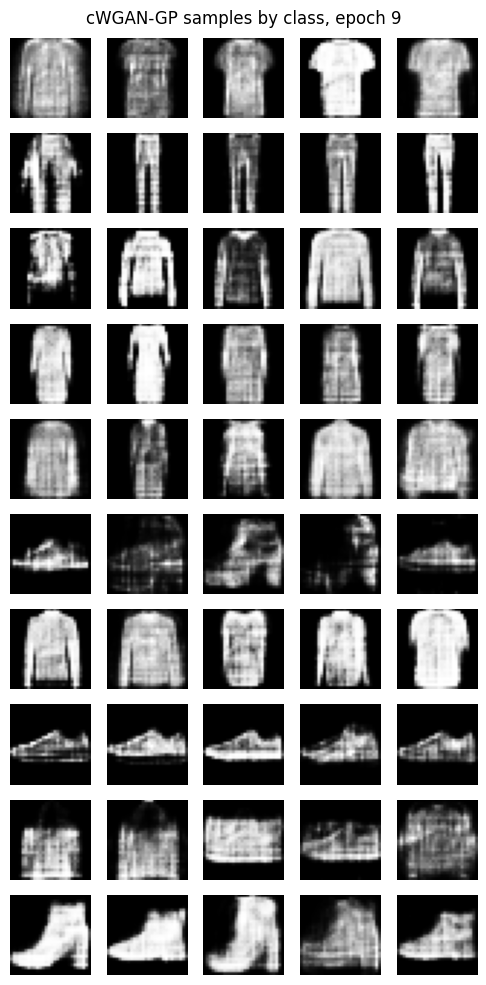

[cWGAN-GP] Epoch [10/10] Step [100/3750] C_loss: -1.1557 | G_loss: 12.1656
[cWGAN-GP] Epoch [10/10] Step [200/3750] C_loss: -1.2301 | G_loss: 13.5409
[cWGAN-GP] Epoch [10/10] Step [300/3750] C_loss: -1.9725 | G_loss: 12.6134
[cWGAN-GP] Epoch [10/10] Step [400/3750] C_loss: -1.4637 | G_loss: 13.6769
[cWGAN-GP] Epoch [10/10] Step [500/3750] C_loss: -1.5427 | G_loss: 13.4606
[cWGAN-GP] Epoch [10/10] Step [600/3750] C_loss: -1.3395 | G_loss: 14.0678
[cWGAN-GP] Epoch [10/10] Step [700/3750] C_loss: -0.8882 | G_loss: 12.7560
[cWGAN-GP] Epoch [10/10] Step [800/3750] C_loss: -1.4365 | G_loss: 13.2560
[cWGAN-GP] Epoch [10/10] Step [900/3750] C_loss: -1.3058 | G_loss: 13.0363
[cWGAN-GP] Epoch [10/10] Step [1000/3750] C_loss: -1.2640 | G_loss: 12.6514
[cWGAN-GP] Epoch [10/10] Step [1100/3750] C_loss: -1.4319 | G_loss: 12.1210
[cWGAN-GP] Epoch [10/10] Step [1200/3750] C_loss: -1.1782 | G_loss: 13.1380
[cWGAN-GP] Epoch [10/10] Step [1300/3750] C_loss: -1.2236 | G_loss: 12.7918
[cWGAN-GP] Epoch [10/

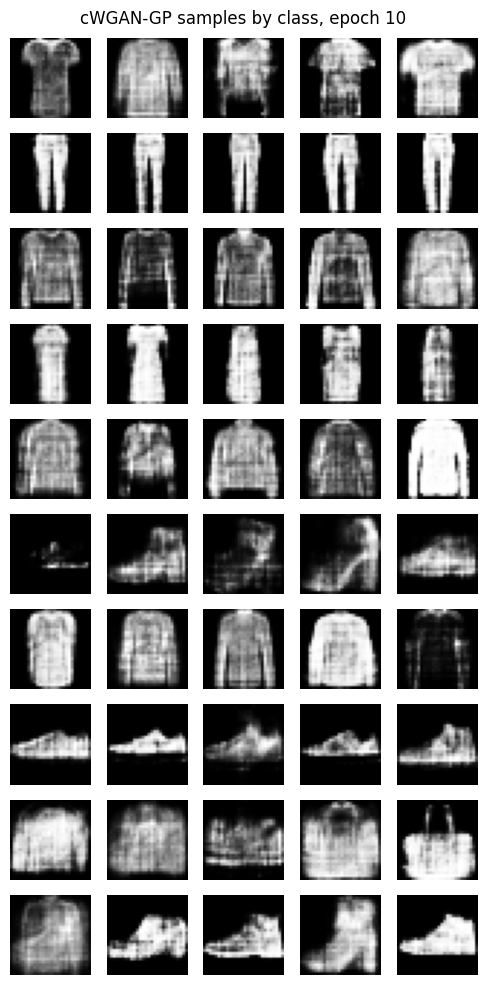

In [49]:
G_losses_c = []
C_losses_c = []

for epoch in range(config_c.num_epochs):
    for i, (real_imgs, labels) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)

        y_onehot = one_hot(labels, num_classes).to(device)

        # === Обучаем критик несколько раз ===
        for _ in range(config_c.n_critic):
            C_c.zero_grad()

            # реальные
            real_scores = C_c(real_imgs, y_onehot)
            loss_real = -real_scores.mean()

            # фейковые (с теми же метками)
            z = torch.randn(batch_size, config_c.noise_size, device=device)
            fake_imgs = G_c(z, y_onehot).detach()
            fake_scores = C_c(fake_imgs, y_onehot)
            loss_fake = fake_scores.mean()

            gp = gradient_penalty_cond(C_c, real_imgs, fake_imgs, y_onehot)

            loss_C = loss_real + loss_fake + config_c.lambda_gp * gp
            loss_C.backward()
            opt_C_c.step()

        # === Обучаем генератор ===
        G_c.zero_grad()
        z = torch.randn(batch_size, config_c.noise_size, device=device)
        fake_imgs = G_c(z, y_onehot)
        fake_scores = C_c(fake_imgs, y_onehot)
        loss_G = -fake_scores.mean()
        loss_G.backward()
        opt_G_c.step()

        G_losses_c.append(loss_G.item())
        C_losses_c.append(loss_C.item())

        if (i + 1) % config_c.print_freq == 0:
            print(
                f"[cWGAN-GP] Epoch [{epoch+1}/{config_c.num_epochs}] "
                f"Step [{i+1}/{len(dataloader)}] "
                f"C_loss: {loss_C.item():.4f} | G_loss: {loss_G.item():.4f}"
            )

    # Немного условных сэмплов после эпохи
    with torch.no_grad():
        num_per_class = 5
        all_imgs = []
        all_labels = []
        for cls in range(num_classes):
            y = torch.full((num_per_class,), cls, dtype=torch.long, device=device)
            y_oh = one_hot(y, num_classes).to(device)
            z = torch.randn(num_per_class, config_c.noise_size, device=device)
            fake_cls = G_c(z, y_oh)  # (num_per_class,1,28,28)
            all_imgs.append(fake_cls.cpu())
            all_labels += [cls]*num_per_class
        all_imgs = torch.cat(all_imgs, dim=0)

        plt.figure(figsize=(num_per_class, num_classes))
        k = 0
        for cls in range(num_classes):
            for j in range(num_per_class):
                plt.subplot(num_classes, num_per_class, k+1)
                plt.imshow(all_imgs[k,0], cmap="gray")
                plt.axis("off")
                if j == 0:
                    plt.ylabel(str(cls))
                k += 1
        plt.suptitle(f"cWGAN-GP samples by class, epoch {epoch+1}")
        plt.tight_layout()
        plt.show()

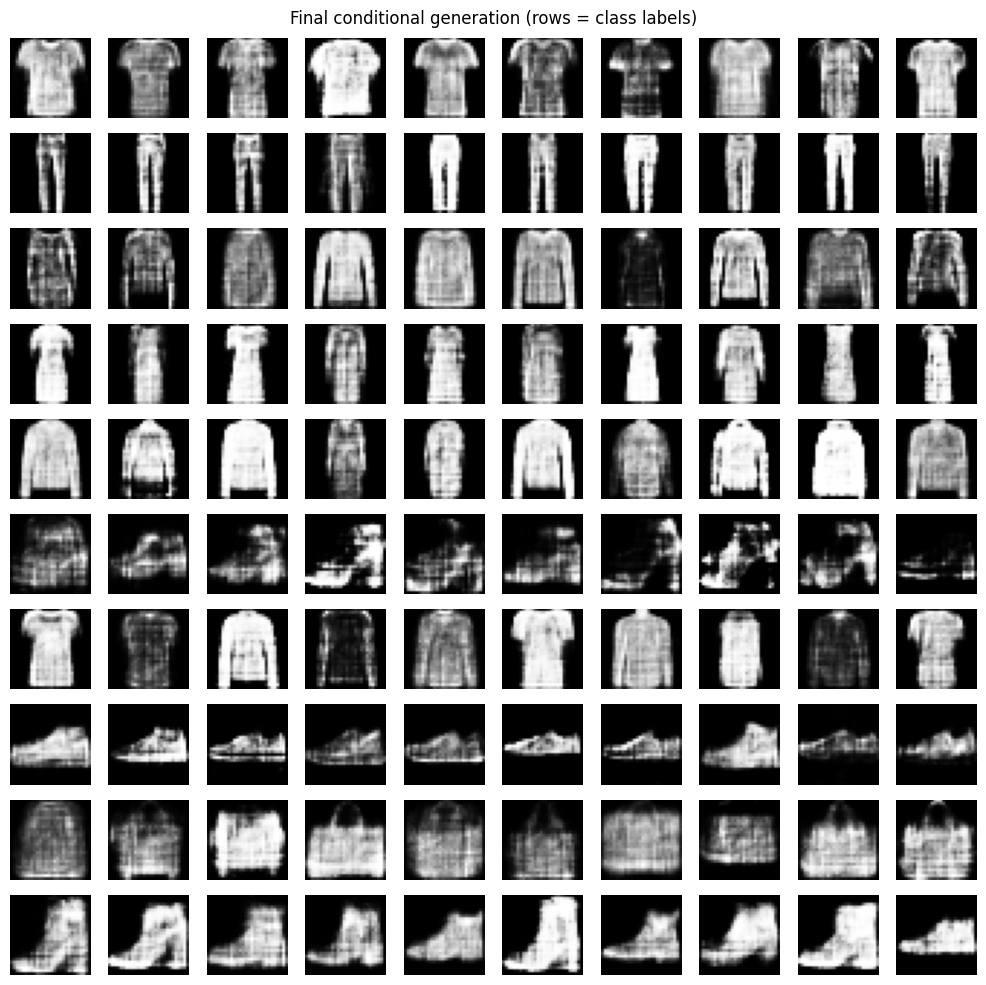

In [ ]:
with torch.no_grad():
    num_per_class = 10
    all_imgs = []
    for cls in range(num_classes):
        y = torch.full((num_per_class,), cls, dtype=torch.long, device=device)
        y_oh = one_hot(y, num_classes).to(device)
        z = torch.randn(num_per_class, config_c.noise_size, device=device)
        fake_cls = G_c(z, y_oh)  # (num_per_class,1,28,28)
        all_imgs.append(fake_cls.cpu())

    all_imgs = torch.cat(all_imgs, dim=0)

plt.figure(figsize=(num_per_class, num_classes))
k = 0
for cls in range(num_classes):
    for j in range(num_per_class):
        plt.subplot(num_classes, num_per_class, k+1)
        plt.imshow(all_imgs[k,0], cmap="gray")
        plt.axis("off")
        if j == 0:
            plt.ylabel(str(cls))
        k += 1
plt.suptitle("Final conditional generation (rows = class labels)")
plt.tight_layout()
plt.show()

каждый класс одежды генерируется на своей строке и визуально соответствует заданной метке.
Каждый класс генерируется устойчиво и с меньшим количеством артефактов.
Видно, что модель выучила не только общую форму одежды, но и специфику каждого класса.